# Model 1A, Experiment 06: Rotation History and Feature Ablation

This controlled sensitivity experiment holds the selected Experiment 05 classifier configuration fixed while changing only rotation-history scope and rotation-feature availability. It compares the original cohort-limited history with full raw BTS airport history, then separates schedule-only, live arrival-state, and complete rotation information. A predeclared 24-hour long-turn sensitivity masks rather than drops questionable matches, preserving the identical departure population.

Every model trains on 2019 and is evaluated once on 2023. Thresholds are selected only from held-out 2019 temporal predictions. The 2024 final-test data are not loaded. Final BTS tail assignment still makes all rotation results retrospective upper bounds.

In [1]:
AIRPORT = "JFK"
TRAIN_YEAR = 2019
VALIDATION_YEAR = 2023
TARGET = "DepDel15"

RANDOM_STATE = 42
N_TIME_SPLITS = 5
LONG_TURN_HOURS = 24

In [2]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    brier_score_loss, f1_score, matthews_corrcoef, precision_score,
    recall_score, roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load paired history datasets

The cohort-limited and full-history files must contain the same target rows, base columns, rotation schema, and target values. Only their reconstructed rotation columns may differ.

In [3]:
def find_project_root(start: Path) -> Path:
    required = [
        Path("data/features") / f"{AIRPORT}_{year}_departures_rotation{suffix}.csv"
        for year in (TRAIN_YEAR, VALIDATION_YEAR)
        for suffix in ("", "_full_history")
    ]
    for candidate in (start, *start.parents):
        if all((candidate / path).is_file() for path in required):
            return candidate
    raise FileNotFoundError(f"Could not locate required experiment files: {required}")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
frames = {}
for history_name, suffix in [("cohort", ""), ("full_history", "_full_history")]:
    for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
        path = PROJECT_ROOT / "data/features" / f"{AIRPORT}_{year}_departures_rotation{suffix}.csv"
        frames[(history_name, partition)] = pd.read_csv(path, low_memory=False)
        print(f"{history_name:12s} {partition:10s}: {len(frames[(history_name, partition)]):,} rows <- {path.name}")

cohort       training  : 107,430 rows <- JFK_2019_departures_rotation.csv


cohort       validation: 109,983 rows <- JFK_2023_departures_rotation.csv


full_history training  : 107,430 rows <- JFK_2019_departures_rotation_full_history.csv


full_history validation: 109,983 rows <- JFK_2023_departures_rotation_full_history.csv


In [4]:
ROTATION_FEATURES = [
    "ROTATION_STATUS", "ROTATION_MATCH_FOUND", "ROTATION_INBOUND_ORIGIN",
    "ROTATION_SCHEDULED_TURN_MINUTES",
    "ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
    "ROTATION_INBOUND_OVERDUE_MINUTES",
    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES",
    "ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_LOG_ACTUAL_TURN_MINUTES",
    "ROTATION_INBOUND_ARR_DELAY", "ROTATION_INBOUND_DELAYED_15",
    "ROTATION_LOG_SCHEDULED_TURN_MINUTES",
]
ROTATION_AUDIT_COLUMNS = [
    "ROTATION_TARGET_CUTOFF_UTC", "ROTATION_PRIOR_REPORTING_AIRLINE",
    "ROTATION_PRIOR_FLIGHT_NUMBER", "ROTATION_PRIOR_FLIGHT_DATE",
    "ROTATION_PRIOR_SCHEDULED_DEPARTURE_UTC",
    "ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC",
    "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC",
    "ROTATION_SCHEDULE_RECONSTRUCTION_ERROR_MINUTES",
]
IDENTITY_COLUMNS = [
    "FlightDate", "Reporting_Airline", "Flight_Number_Reporting_Airline",
    "Origin", "Dest", "CRSDepTime", "Tail_Number", TARGET,
]

validation_rows = []
for partition, year in [("training", TRAIN_YEAR), ("validation", VALIDATION_YEAR)]:
    cohort = frames[("cohort", partition)]
    full = frames[("full_history", partition)]
    required = {"FlightDate", "DATE", "Origin", TARGET, *ROTATION_FEATURES, *ROTATION_AUDIT_COLUMNS}
    assert not required.difference(cohort.columns) and not required.difference(full.columns)
    assert len(cohort) == len(full)
    pd.testing.assert_frame_equal(cohort[IDENTITY_COLUMNS], full[IDENTITY_COLUMNS], check_dtype=False)
    for name, frame in [("cohort", cohort), ("full_history", full)]:
        frame["FlightDate"] = pd.to_datetime(frame["FlightDate"], errors="raise")
        assert frame["FlightDate"].dt.year.eq(year).all() and frame["Origin"].eq(AIRPORT).all()
        match = pd.to_numeric(frame["ROTATION_MATCH_FOUND"], errors="raise")
        arrived = pd.to_numeric(frame["ROTATION_INBOUND_ARRIVED_BY_CUTOFF"], errors="raise")
        not_arrived = pd.to_numeric(frame["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise")
        assert match.eq(arrived + not_arrived).all()
        actual_only = ["ROTATION_ACTUAL_TURN_MINUTES", "ROTATION_INBOUND_ARR_DELAY",
                       "ROTATION_INBOUND_DELAYED_15", "ROTATION_PRIOR_ACTUAL_ARRIVAL_UTC"]
        assert not frame.loc[arrived.eq(0), actual_only].notna().any().any()
        long_turn = pd.to_numeric(frame["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
        validation_rows.append({
            "partition": partition, "history": name, "rows": len(frame),
            "delay_rate": frame[TARGET].mean(), "match_rate": match.mean(),
            "not_arrived_rows": int(not_arrived.sum()),
            "not_arrived_delay_rate": frame.loc[not_arrived.eq(1), TARGET].mean(),
            "turns_over_24h": int(long_turn.sum()),
        })
source_summary = pd.DataFrame(validation_rows).set_index(["partition", "history"])
source_summary

rows  delay_rate  match_rate  not_arrived_rows  \
partition  history                                                          
training   cohort        107430      0.1877      0.9564              2638   
           full_history  107430      0.1877      0.9665              3133   
validation cohort        109983      0.2364      0.9339              2995   
           full_history  109983      0.2364      0.9554              3565   

                         not_arrived_delay_rate  turns_over_24h  
partition  history                                               
training   cohort                        0.9977           10668  
           full_history                  0.9981            8281  
validation cohort                        0.9963           10822  
           full_history                  0.9969            8409

## Predeclared feature ablations

The raw baseline contains no rotation fields. Schedule-only uses tail assignment and scheduled leg order but no live arrival event or realized inbound outcome. State-only isolates whether the assigned aircraft has arrived by the cutoff. Full uses all 13 rotation fields. The long-turn sensitivity replaces full-history matches over 24 hours with a distinct `LONG_TURN_EXCLUDED` state and masks every other rotation value; it never removes target rows.

In [5]:
BASE_CATEGORICAL_FEATURES = ["Month", "DayOfWeek", "Reporting_Airline", "Dest"]
BASE_NUMERIC_FEATURES = [
    "CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES", "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES", "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES", "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature", "HourlyDryBulbTemperature",
    "HourlyPrecipitation", "HourlyRelativeHumidity",
    "HourlyVisibility", "HourlyWindSpeed",
]
FULL_ROTATION_CATEGORICAL = ["ROTATION_STATUS", "ROTATION_INBOUND_ORIGIN"]
FULL_ROTATION_NUMERIC = [c for c in ROTATION_FEATURES if c not in FULL_ROTATION_CATEGORICAL]
VARIANTS = {
    "raw_baseline": {"history": "full_history", "categorical": [], "numeric": []},
    "cohort_full": {"history": "cohort", "categorical": FULL_ROTATION_CATEGORICAL, "numeric": FULL_ROTATION_NUMERIC},
    "full_history_schedule_only": {
        "history": "full_history", "categorical": ["ROTATION_INBOUND_ORIGIN"],
        "numeric": ["ROTATION_MATCH_FOUND", "ROTATION_LOG_SCHEDULED_TURN_MINUTES"],
    },
    "full_history_state_only": {
        "history": "full_history", "categorical": ["ROTATION_STATUS"],
        "numeric": ["ROTATION_INBOUND_ARRIVED_BY_CUTOFF",
                    "ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF",
                    "ROTATION_LOG_INBOUND_OVERDUE_MINUTES"],
    },
    "full_history_full": {"history": "full_history", "categorical": FULL_ROTATION_CATEGORICAL, "numeric": FULL_ROTATION_NUMERIC},
    "full_history_full_max_24h": {"history": "full_history_mask_24h", "categorical": FULL_ROTATION_CATEGORICAL, "numeric": FULL_ROTATION_NUMERIC},
}
FORBIDDEN_PREDICTORS = {
    TARGET, "DepTime", "DepDelay", "DepDelayMinutes", "TaxiOut",
    "WheelsOff", "WheelsOn", "TaxiIn", "ArrTime", "ArrDelay",
    "ArrDelayMinutes", "ArrDel15", "ActualElapsedTime", "AirTime",
    "Tail_Number", *ROTATION_AUDIT_COLUMNS,
}
manifest_summary = pd.DataFrame({
    name: {"history": spec["history"],
           "base_fields": len(BASE_CATEGORICAL_FEATURES) + len(BASE_NUMERIC_FEATURES),
           "rotation_fields": len(spec["categorical"]) + len(spec["numeric"])}
    for name, spec in VARIANTS.items()
}).T
assert all(not FORBIDDEN_PREDICTORS.intersection(
    BASE_CATEGORICAL_FEATURES + BASE_NUMERIC_FEATURES + spec["categorical"] + spec["numeric"]
) for spec in VARIANTS.values())
manifest_summary

,history,base_fields,rotation_fields
raw_baseline,full_history,20,0
cohort_full,cohort,20,13
full_history_schedule_only,full_history,20,3
full_history_state_only,full_history,20,4
full_history_full,full_history,20,13
full_history_full_max_24h,full_history_mask_24h,20,13


In [6]:
def mask_long_turns(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()
    long_turn = pd.to_numeric(result["ROTATION_SCHEDULED_TURN_MINUTES"], errors="coerce").gt(LONG_TURN_HOURS * 60)
    result.loc[long_turn, ROTATION_FEATURES] = np.nan
    result.loc[long_turn, "ROTATION_STATUS"] = "LONG_TURN_EXCLUDED"
    return result


frames[("full_history_mask_24h", "training")] = mask_long_turns(frames[("full_history", "training")])
frames[("full_history_mask_24h", "validation")] = mask_long_turns(frames[("full_history", "validation")])

def prepare_frame(frame: pd.DataFrame, categorical, numeric):
    columns = ["FlightDate", "CRSDepTime", TARGET, *BASE_CATEGORICAL_FEATURES,
               *BASE_NUMERIC_FEATURES, *categorical, *numeric]
    columns = list(dict.fromkeys(columns))
    result = frame[columns].copy().sort_values(["FlightDate", "CRSDepTime"], kind="stable").reset_index(drop=True)
    result[TARGET] = pd.to_numeric(result[TARGET], errors="raise").astype(int)
    for column in [*BASE_CATEGORICAL_FEATURES, *categorical]:
        result[column] = result[column].astype(object)
    for column in [*BASE_NUMERIC_FEATURES, *numeric]:
        result[column] = pd.to_numeric(result[column], errors="coerce")
    return result


def make_expanding_day_splits(dates: pd.Series, targets: pd.Series, n_splits: int):
    normalized = dates.dt.normalize().to_numpy()
    day_blocks = np.array_split(np.array(sorted(pd.unique(normalized))), n_splits + 1)
    splits, rows = [], []
    for fold in range(1, n_splits + 1):
        train_days, validation_days = np.concatenate(day_blocks[:fold]), day_blocks[fold]
        train_idx = np.flatnonzero(np.isin(normalized, train_days))
        validation_idx = np.flatnonzero(np.isin(normalized, validation_days))
        assert train_days.max() < validation_days.min()
        splits.append((train_idx, validation_idx))
        rows.append({"fold": fold, "train_rows": len(train_idx),
                     "validation_rows": len(validation_idx),
                     "train_end": pd.Timestamp(train_days.max()).date(),
                     "validation_start": pd.Timestamp(validation_days.min()).date(),
                     "validation_end": pd.Timestamp(validation_days.max()).date(),
                     "validation_delay_rate": targets.iloc[validation_idx].mean()})
    return splits, pd.DataFrame(rows).set_index("fold")

reference = prepare_frame(frames[("full_history", "training")], [], [])
temporal_splits, fold_summary = make_expanding_day_splits(
    reference["FlightDate"], reference[TARGET], N_TIME_SPLITS
)
fold_summary

,train_rows,validation_rows,train_end,validation_start,validation_end,validation_delay_rate
fold,,,,,,
1,17737,18776,2019-03-02,2019-03-03,2019-05-02,0.1674
2,36513,18150,2019-05-02,2019-05-03,2019-07-02,0.2072
3,54663,17758,2019-07-02,2019-07-03,2019-09-01,0.2577
4,72421,17686,2019-09-01,2019-09-02,2019-11-01,0.1384
5,90107,17323,2019-11-01,2019-11-02,2019-12-31,0.1666


## Fixed Experiment 05 classifier and training-only thresholds

Every variant uses L2 logistic regression with `C=1`, no class weighting, all nonconstant prepared columns, and the same preprocessing as Experiment 05. No hyperparameter or variant is selected from 2023. Each variant receives its own F1 threshold selected from its held-out 2019 temporal probabilities.

In [7]:
def make_pipeline(categorical, numeric):
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", StandardScaler()),
    ])
    return Pipeline([
        ("preprocessor", ColumnTransformer([
            ("categorical", categorical_pipeline, categorical),
            ("numeric", numeric_pipeline, numeric),
        ], remainder="drop")),
        ("variance_filter", VarianceThreshold(0.0)),
        ("classifier", LogisticRegression(
            C=1.0, l1_ratio=0.0, solver="liblinear", class_weight=None,
            max_iter=5_000, random_state=RANDOM_STATE,
        )),
    ])


def classification_metrics(y, probabilities, threshold):
    predictions = (np.asarray(probabilities) >= threshold).astype(int)
    return {
        "threshold": threshold, "accuracy": accuracy_score(y, predictions),
        "balanced_accuracy": balanced_accuracy_score(y, predictions),
        "precision": precision_score(y, predictions, zero_division=0),
        "recall": recall_score(y, predictions, zero_division=0),
        "f1": f1_score(y, predictions, zero_division=0),
        "mcc": matthews_corrcoef(y, predictions),
        "roc_auc": roc_auc_score(y, probabilities),
        "average_precision": average_precision_score(y, probabilities),
        "brier_score": brier_score_loss(y, probabilities),
    }


models, validation_probabilities, result_rows, threshold_rows = {}, {}, [], []
experiment_start = perf_counter()
for variant_name, spec in VARIANTS.items():
    categorical = [*BASE_CATEGORICAL_FEATURES, *spec["categorical"]]
    numeric = [*BASE_NUMERIC_FEATURES, *spec["numeric"]]
    train = prepare_frame(frames[(spec["history"], "training")], spec["categorical"], spec["numeric"])
    validation = prepare_frame(frames[(spec["history"], "validation")], spec["categorical"], spec["numeric"])
    features = [*categorical, *numeric]
    X_train, y_train = train[features], train[TARGET]
    X_validation, y_validation = validation[features], validation[TARGET]
    base_pipeline = make_pipeline(categorical, numeric)
    oof = np.full(len(train), np.nan)
    fold_ap = []
    for train_idx, heldout_idx in temporal_splits:
        fold_model = clone(base_pipeline).fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        fold_p = fold_model.predict_proba(X_train.iloc[heldout_idx])[:, 1]
        oof[heldout_idx] = fold_p
        fold_ap.append(average_precision_score(y_train.iloc[heldout_idx], fold_p))
    oof_mask = np.isfinite(oof)
    candidates = []
    for threshold in np.round(np.arange(0.05, 0.501, 0.01), 2):
        metrics = classification_metrics(y_train.to_numpy()[oof_mask], oof[oof_mask], threshold)
        candidates.append(metrics)
    threshold_table = pd.DataFrame(candidates)
    selected_threshold = float(threshold_table.sort_values(
        ["f1", "balanced_accuracy", "precision"], ascending=False
    ).iloc[0]["threshold"])
    final_model = clone(base_pipeline).fit(X_train, y_train)
    probabilities = final_model.predict_proba(X_validation)[:, 1]
    models[variant_name] = final_model
    validation_probabilities[variant_name] = probabilities
    encoded = final_model.named_steps["preprocessor"].get_feature_names_out()
    nonconstant = encoded[final_model.named_steps["variance_filter"].get_support()]
    for policy, threshold in [("default", 0.50), ("training_selected", selected_threshold)]:
        row = classification_metrics(y_validation, probabilities, threshold)
        row.update({"variant": variant_name, "threshold_policy": policy,
                    "training_cv_ap": np.mean(fold_ap),
                    "prepared_columns": len(nonconstant),
                    "rotation_fields": len(spec["categorical"]) + len(spec["numeric"])})
        result_rows.append(row)
    threshold_rows.append({"variant": variant_name, "selected_threshold": selected_threshold})
    print(f"Completed {variant_name}: CV AP={np.mean(fold_ap):.4f}, 2023 AP={average_precision_score(y_validation, probabilities):.4f}")
experiment_seconds = perf_counter() - experiment_start
results = pd.DataFrame(result_rows).set_index(["variant", "threshold_policy"])
print(f"Total Experiment 06 fitting time: {experiment_seconds:,.1f} seconds")
results[["training_cv_ap", "average_precision", "roc_auc", "brier_score",
         "threshold", "accuracy", "balanced_accuracy", "precision",
         "recall", "f1", "mcc", "prepared_columns"]]

Completed raw_baseline: CV AP=0.3007, 2023 AP=0.3988


Completed cohort_full: CV AP=0.5930, 2023 AP=0.6515


Completed full_history_schedule_only: CV AP=0.3383, 2023 AP=0.4417


Completed full_history_state_only: CV AP=0.4894, 2023 AP=0.5658


Completed full_history_full: CV AP=0.6292, 2023 AP=0.6848


Completed full_history_full_max_24h: CV AP=0.6375, 2023 AP=0.6960
Total Experiment 06 fitting time: 47.8 seconds


training_cv_ap  \
variant                    threshold_policy                    
raw_baseline               default                    0.3007   
                           training_selected          0.3007   
cohort_full                default                    0.5930   
                           training_selected          0.5930   
full_history_schedule_only default                    0.3383   
                           training_selected          0.3383   
full_history_state_only    default                    0.4894   
                           training_selected          0.4894   
full_history_full          default                    0.6292   
                           training_selected          0.6292   
full_history_full_max_24h  default                    0.6375   
                           training_selected          0.6375   

                                              average_precision  roc_auc  \
variant                    threshold_policy                                
raw_baseline               default                       0.3988   0.6829   
                           training_selected             0.3988   0.6829   
cohort_full                default                       0.6515   0.7932   
                           training_selected             0.6515   0.7932   
full_history_schedule_only default                       0.4417   0.7010   
                           training_selected             0.4417   0.7010   
full_history_state_only    default                       0.5658   0.7446   
                           training_selected             0.5658   0.7446   
full_history_full          default                       0.6848   0.8091   
                           training_selected             0.6848   0.8091   
full_history_full_max_24h  default                       0.6960   0.8188   
                           training_selected             0.6960   0.8188   

                                              brier_score  threshold  \
variant                    threshold_policy                            
raw_baseline               default                 0.1690     0.5000   
                           training_selected       0.1690     0.1500   
cohort_full                default                 0.1316     0.5000   
                           training_selected       0.1316     0.2600   
full_history_schedule_only default                 0.1640     0.5000   
                           training_selected       0.1640     0.1600   
full_history_state_only    default                 0.1472     0.5000   
                           training_selected       0.1472     0.2100   
full_history_full          default                 0.1245     0.5000   
                           training_selected       0.1245     0.2800   
full_history_full_max_24h  default                 0.1222     0.5000   
                           training_selected       0.1222     0.3100   

                                              accuracy  balanced_accuracy  \
variant                    threshold_policy                                 
raw_baseline               default              0.7660             0.5114   
                           training_selected    0.5751             0.6289   
cohort_full                default              0.8251             0.6486   
                           training_selected    0.8053             0.7115   
full_history_schedule_only default              0.7740             0.5358   
                           training_selected    0.6078             0.6409   
full_history_state_only    default              0.8048             0.5970   
                           training_selected    0.7437             0.6698   
full_history_full          default              0.8371             0.6767   
                           training_selected    0.8253             0.7239   
full_history_full_max_24h  default              0.8401             0.6825   
                           training_selected    0.8319             0.7236 

## Paired history and subgroup diagnostics

The main comparison uses all 2023 rows. These diagnostics determine whether fuller history changes ranking specifically where the reconstructed preceding inbound differs, and whether discrimination remains after excluding the nearly deterministic `NOT_ARRIVED` group.

In [8]:
cohort = frames[("cohort", "validation")]
full = frames[("full_history", "validation")]
y_validation = pd.to_numeric(full[TARGET], errors="raise").astype(int)
cohort_prior = pd.to_datetime(cohort["ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC"], errors="coerce")
full_prior = pd.to_datetime(full["ROTATION_PRIOR_SCHEDULED_ARRIVAL_UTC"], errors="coerce")
history_changed = ~(cohort_prior.eq(full_prior) | (cohort_prior.isna() & full_prior.isna()))
full_not_arrived = pd.to_numeric(full["ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF"], errors="raise").eq(1)
diagnostic_rows = []
for model_name in ["cohort_full", "full_history_full", "full_history_full_max_24h"]:
    probabilities = validation_probabilities[model_name]
    for population, mask in [("all rows", np.ones(len(full), dtype=bool)),
                             ("history changed", history_changed.to_numpy()),
                             ("history unchanged", ~history_changed.to_numpy()),
                             ("excluding NOT_ARRIVED", ~full_not_arrived.to_numpy())]:
        diagnostic_rows.append({
            "model": model_name, "population": population, "rows": int(mask.sum()),
            "prevalence": y_validation.to_numpy()[mask].mean(),
            "average_precision": average_precision_score(y_validation.to_numpy()[mask], probabilities[mask]),
            "roc_auc": roc_auc_score(y_validation.to_numpy()[mask], probabilities[mask]),
            "brier_score": brier_score_loss(y_validation.to_numpy()[mask], probabilities[mask]),
        })
diagnostic_results = pd.DataFrame(diagnostic_rows).set_index(["population", "model"])
print(pd.Series({"history-changed rows": int(history_changed.sum()),
                 "history-changed percent": history_changed.mean() * 100,
                 "full-history NOT_ARRIVED rows": int(full_not_arrived.sum()),
                 "NOT_ARRIVED delay rate": y_validation.loc[full_not_arrived].mean()}))
diagnostic_results

history-changed rows            12,166.0000
history-changed percent             11.0617
full-history NOT_ARRIVED rows    3,565.0000
NOT_ARRIVED delay rate               0.9969
dtype: float64


,,rows,prevalence,average_precision,roc_auc,brier_score
population,model,,,,,
all rows,cohort_full,109983,0.2364,0.6515,0.7932,0.1316
history changed,cohort_full,12166,0.2237,0.3334,0.6505,0.1692
history unchanged,cohort_full,97817,0.2379,0.6801,0.8066,0.1270
excluding NOT_ARRIVED,cohort_full,106418,0.2109,0.5587,0.7660,0.1330
all rows,full_history_full,109983,0.2364,0.6848,0.8091,0.1245
history changed,full_history_full,12166,0.2237,0.7203,0.8331,0.1095
history unchanged,full_history_full,97817,0.2379,0.6804,0.8058,0.1264
excluding NOT_ARRIVED,full_history_full,106418,0.2109,0.5871,0.7790,0.1286
all rows,full_history_full_max_24h,109983,0.2364,0.6960,0.8188,0.1222


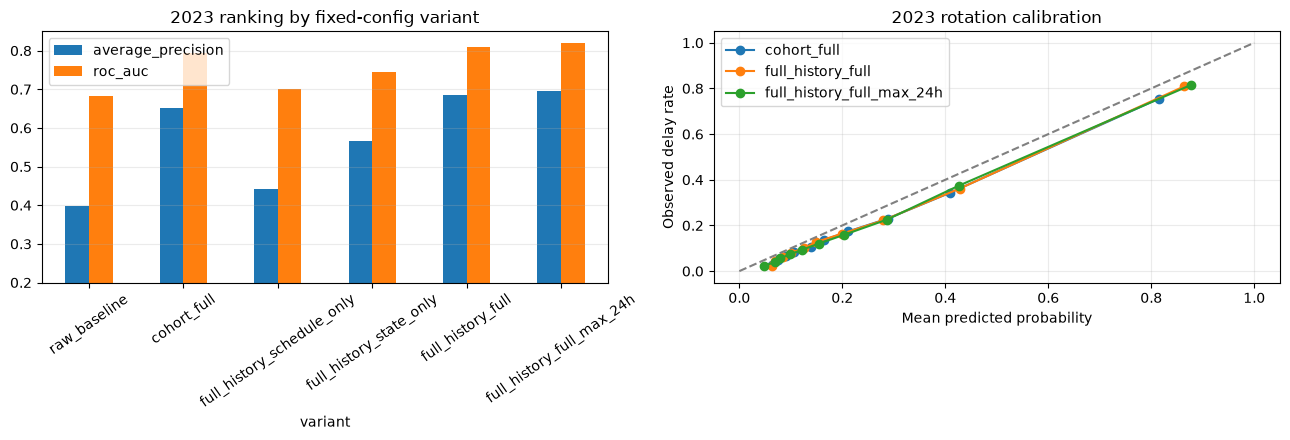

In [9]:
ranking = results.xs("default", level="threshold_policy")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
ranking[["average_precision", "roc_auc"]].plot.bar(ax=axes[0], rot=35)
axes[0].set_title("2023 ranking by fixed-config variant")
axes[0].set_ylim(0.2, 0.85); axes[0].grid(axis="y", alpha=0.25)
for name in ["cohort_full", "full_history_full", "full_history_full_max_24h"]:
    predicted, observed = calibration_curve(
        y_validation, validation_probabilities[name], n_bins=10, strategy="quantile"
    )
    axes[1].plot(predicted, observed, marker="o", label=name)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set(xlabel="Mean predicted probability", ylabel="Observed delay rate",
            title="2023 rotation calibration")
axes[1].legend(); axes[1].grid(alpha=0.25)
fig.tight_layout(); plt.show()

## Inspect the full-history model and publishable values

Coefficient magnitudes describe associations after encoding and standardization. They do not establish that a rotation state caused the target delay.

In [10]:
selected_model = models["full_history_full_max_24h"]
encoded = selected_model.named_steps["preprocessor"].get_feature_names_out()
selected_names = encoded[selected_model.named_steps["variance_filter"].get_support()]
coefficients = (pd.Series(selected_model.named_steps["classifier"].coef_[0], index=selected_names, name="coefficient")
    .rename_axis("feature").reset_index()
    .assign(abs_coefficient=lambda frame: frame["coefficient"].abs())
    .sort_values("abs_coefficient", ascending=False))
display(coefficients.head(25))
display(coefficients[coefficients["feature"].str.contains("ROTATION_", regex=False)])

default = results.xs("default", level="threshold_policy")
selected = results.xs("training_selected", level="threshold_policy")
publishable_summary = pd.Series({
    "selected interpretation variant": "full_history_full_max_24h",
    "classifier": "L2 logistic regression, C=1, no class weighting",
    "feature selection": "all nonconstant prepared columns",
    "training CV AP": default.loc["full_history_full_max_24h", "training_cv_ap"],
    "validation prevalence": y_validation.mean(),
    "validation AP": default.loc["full_history_full_max_24h", "average_precision"],
    "validation ROC AUC": default.loc["full_history_full_max_24h", "roc_auc"],
    "validation Brier": default.loc["full_history_full_max_24h", "brier_score"],
    "selected threshold": selected.loc["full_history_full_max_24h", "threshold"],
    "selected-threshold accuracy": selected.loc["full_history_full_max_24h", "accuracy"],
    "selected-threshold balanced accuracy": selected.loc["full_history_full_max_24h", "balanced_accuracy"],
    "selected-threshold precision": selected.loc["full_history_full_max_24h", "precision"],
    "selected-threshold recall": selected.loc["full_history_full_max_24h", "recall"],
    "selected-threshold F1": selected.loc["full_history_full_max_24h", "f1"],
    "selected-threshold MCC": selected.loc["full_history_full_max_24h", "mcc"],
    "validation AP excluding NOT_ARRIVED": diagnostic_results.loc[("excluding NOT_ARRIVED", "full_history_full_max_24h"), "average_precision"],
    "fit seconds": experiment_seconds,
}, name="Experiment 06 Appendix E values")
publishable_summary.to_frame()

,feature,coefficient,abs_coefficient
178,numeric__ROTATION_LOG_ACTUAL_TURN_MINUTES,-2.8212,2.8212
181,numeric__ROTATION_LOG_SCHEDULED_TURN_MINUTES,1.9752,1.9752
45,categorical__Dest_HNL,1.1123,1.1123
174,numeric__ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,1.0879,1.0879
26,categorical__Reporting_Airline_OH,-1.0429,1.0429
79,categorical__ROTATION_STATUS_ARRIVED,-0.9304,0.9304
152,categorical__ROTATION_INBOUND_ORIGIN_STT,0.8271,0.8271
110,categorical__ROTATION_INBOUND_ORIGIN_IAD,-0.8096,0.8096
28,categorical__Reporting_Airline_YX,-0.7958,0.7958
107,categorical__ROTATION_INBOUND_ORIGIN_HNL,-0.6268,0.6268


,feature,coefficient,abs_coefficient
178,numeric__ROTATION_LOG_ACTUAL_TURN_MINUTES,-2.8212,2.8212
181,numeric__ROTATION_LOG_SCHEDULED_TURN_MINUTES,1.9752,1.9752
174,numeric__ROTATION_INBOUND_NOT_ARRIVED_BY_CUTOFF,1.0879,1.0879
79,categorical__ROTATION_STATUS_ARRIVED,-0.9304,0.9304
152,categorical__ROTATION_INBOUND_ORIGIN_STT,0.8271,0.8271
...,...,...,...
106,categorical__ROTATION_INBOUND_ORIGIN_FLL,0.0128,0.0128
133,categorical__ROTATION_INBOUND_ORIGIN_PSE,-0.0123,0.0123
114,categorical__ROTATION_INBOUND_ORIGIN_JAX,0.0117,0.0117
142,categorical__ROTATION_INBOUND_ORIGIN_SAT,0.0050,0.0050


,Experiment 06 Appendix E values
selected interpretation variant,full_history_full_max_24h
classifier,"L2 logistic regression, C=1, no class weighting"
feature selection,all nonconstant prepared columns
training CV AP,0.6375
validation prevalence,0.2364
validation AP,0.6960
validation ROC AUC,0.8188
validation Brier,0.1222
selected threshold,0.3100
selected-threshold accuracy,0.8319


## Interpretation checklist

1. Does full raw airport history improve 2019 temporal AP and untouched 2023 AP, ROC AUC, or Brier score relative to cohort-limited history under the identical classifier?
2. How much information is available from scheduled rotation alone versus live arrival state and already-observed inbound outcomes?
3. Does masking turns longer than 24 hours improve generalization, or discard useful true rotations?
4. Are changes concentrated in rows whose preceding inbound reconstruction changed?
5. Does useful ranking remain after `NOT_ARRIVED` rows are excluded?
6. Keep the final-tail assignment caveat: all rotation variants remain retrospective upper bounds until a timestamped assignment feed is available.